In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

!pip install keras-tuner --upgrade

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.1/168.1 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 46.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 56.9 MB/s eta 0:00:00
  Attempting uninstall: typing-extensions
    Found existing installation: typing_extensions 4.1.1
    Uninstalling typing_extensions-4.1.1:
      Successfully uninstalled typing_extensions-4.1.1
  Attempting uninstall: numpy
    Found existing installation: numpy 1.21.6
    Uninstalling numpy-1.21.6:
      Successfully uninstalled numpy-1.21.6
  Attempting uninstall: h5py
    Found existing installation: h5py 3.7.0
    Uninstalling h5py-3.7.0:
      Successfully uninstalled h5py-3.7.0
  Attempting uninstall: keras-tuner
    Found existing installation: keras-tuner 1.1.2
    Uninstalling keras-tuner-1.1.2:
      Successfully uninstalled keras-tuner-1.1.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are 

In [2]:
train_df = pd.read_csv('/kaggle/input/playground-series-s3e4/train.csv')
test_df = pd.read_csv('/kaggle/input/playground-series-s3e4/test.csv')
submission = pd.read_csv('/kaggle/input/playground-series-s3e4/sample_submission.csv')
addition_data = pd.read_csv('/kaggle/input/creditcardfraud/creditcard.csv')

train_df['is_generated'] = 1
test_df['is_generated'] = 1
addition_data['is_generated'] = 0

In [3]:
train_df = pd.concat([train_df, addition_data],axis=0, ignore_index=True)

In [4]:
df = pd.concat([train_df, test_df], axis=0)

In [5]:
df['hour'] = df['Time'] % (24 * 3600) // 3600
df['day'] = (df['Time'] // (24 * 3600)) % 7

In [6]:
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()

# y = df['Class']
# df = df.drop(['id','Class'], axis=1)

# df[df.columns] = scaler.fit_transform(df[df.columns])

In [7]:
from sklearn.preprocessing import RobustScaler
rscale = RobustScaler()

y = df['Class']
df = df.drop(['id','Class'], axis=1)

df['Amount']=rscale.fit_transform(df['Amount'].values.reshape(-1,1))
df['Time']=rscale.fit_transform(df['Time'].values.reshape(-1,1))

In [8]:
train_df = df.iloc[:-len(test_df),:]
train_df['Class'] = y[:-len(test_df)]
test_df = df.iloc[-len(test_df):,:].reset_index(drop=True)

oversample = train_df[train_df['Class']==1]
undersample = train_df[train_df['Class']==0]
sample_size = 200000

X = train_df.drop(['Class'], axis=1)
y = train_df.Class
X_test = test_df

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


**Keras NN**

In [9]:
from tensorflow import keras
import tensorflow_addons as tfa
from tensorflow.keras import layers

import keras_tuner

from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, Lambda, Concatenate, Add, BatchNormalization, LeakyReLU

from sklearn.model_selection import KFold, StratifiedKFold, RepeatedStratifiedKFold

from sklearn.model_selection import train_test_split

from sklearn.metrics import classification_report

In [10]:
models = []
preds = []

class_weight = 10 

n_folds = 2 
repeats = 20
dr = 0.1     

# k_fold = StratifiedKFold(n_splits=n_folds, random_state=42, shuffle=True)
k_fold = RepeatedStratifiedKFold(n_splits=n_folds, n_repeats=repeats, random_state=42)

def get_model():
    model = keras.Sequential([
#     layers.Dense(512), 
#     layers.LeakyReLU(alpha=0.3),
#     layers.Dropout(rate=dr),
    layers.Dense(256), 
    layers.LeakyReLU(alpha=0.3),
    layers.Dropout(rate=dr),
    layers.Dense(128), 
    layers.LeakyReLU(alpha=0.3),
    layers.Dropout(rate=dr),
    layers.Dense(64), 
    layers.LeakyReLU(alpha=0.3),
    layers.Dropout(rate=dr),
    layers.BatchNormalization(),
    layers.Dense(32), 
    layers.LeakyReLU(alpha=0.3),
    layers.Dropout(rate=dr),
    layers.Dense(16), 
    layers.LeakyReLU(alpha=0.3),
    layers.Dropout(rate=dr),
    layers.Dense(8),
    layers.LeakyReLU(alpha=0.3),
    layers.Dropout(rate=dr),
    layers.Dense(4), 
    layers.LeakyReLU(alpha=0.3),
    layers.Dense(2), 
    layers.LeakyReLU(alpha=0.3),
    layers.Dense(1, activation='sigmoid')
   ])

    opt = keras.optimizers.Adam(learning_rate=0.0001)
    
    model.compile(
    optimizer=opt,
        loss=tfa.losses.SigmoidFocalCrossEntropy(
                                             alpha= 0.4, #0.8,
                                             gamma= 3.5, #hp.Choice('units', [3.0, 3.5, 4.0]) #2.0
                                             ),
        metrics='AUC',
)
    
    return model

# tuner1 = keras_tuner.RandomSearch(
#     get_model,
#     objective=keras_tuner.Objective("val_auc", direction="max"),
#     max_trials=5,
#     overwrite=True)

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33)

# tuner1.search(X_train, y_train, epochs=5, validation_data=(X_test, y_test))
# best_model = tuner1.get_best_models()[0]

In [11]:
# tuner1.results_summary()

In [12]:

early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_auc", 
        mode='max',
        patience=10,
        min_delta=0.00001,
        restore_best_weights=True,
)
plat = keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc", 
        mode='max', 
        patience=3, 
        factor=0.1, 
        min_lr=1e-8, 
        min_delta=0.000001)


# for train_index, test_index in k_fold.split(X, y):
#     X_train, X_valid = X.iloc[train_index], X.iloc[test_index]
#     y_train, y_valid = y.iloc[train_index], y.iloc[test_index]
    
#     model = get_model()

#     history = model.fit(
#           X_train, y_train,
#           validation_data=(X_valid, y_valid),
#           batch_size=256,
#           epochs=500,
#           class_weight = { 0: 1.0, 1: class_weight, },
#           callbacks=[early_stopping, plat],
#           verbose=1
#          )
    
# #     print(classification_report(y, np.round(model.predict(X))))
#     models.append(model)
#     preds.append(model.predict(X_test))
    
for i in range(repeats):
    sample = undersample.sample(n=sample_size)
    merged = pd.concat([oversample,sample])
    X = merged.drop('Class', axis=1)
    y = merged['Class']
    
    model = get_model()
    
    X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.25)

    history = model.fit(
          X_train, y_train,
          validation_data=(X_valid, y_valid),
          batch_size=256,
          epochs=500,
          class_weight = { 0: 1.0, 1: class_weight, },
          callbacks=[early_stopping, plat],
          verbose=1
    )
    
    models.append(model)
    preds.append(model.predict(X_test))

2023-01-29 15:58:17.195210: I tensorflow/core/common_runtime/process_util.cc:146] Creating new thread pool with default inter op setting: 2. Tune using inter_op_parallelism_threads for best performance.
2023-01-29 15:58:17.628589: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:185] None of the MLIR Optimization Passes are enabled (registered 2)


Epoch 1/500
589/589 [==============================] - 10s 13ms/step - loss: 0.0193 - auc: 0.6945 - val_loss: 0.0059 - val_auc: 0.7994
Epoch 2/500
589/589 [==============================] - 6s 11ms/step - loss: 0.0079 - auc: 0.8325 - val_loss: 0.0025 - val_auc: 0.8545
Epoch 3/500
589/589 [==============================] - 6s 11ms/step - loss: 0.0065 - auc: 0.8737 - val_loss: 0.0019 - val_auc: 0.8739
Epoch 4/500
589/589 [==============================] - 6s 11ms/step - loss: 0.0062 - auc: 0.8806 - val_loss: 0.0020 - val_auc: 0.8810
Epoch 5/500
589/589 [==============================] - 6s 11ms/step - loss: 0.0056 - auc: 0.9023 - val_loss: 0.0019 - val_auc: 0.8938
Epoch 6/500
589/589 [==============================] - 7s 11ms/step - loss: 0.0056 - auc: 0.9045 - val_loss: 0.0023 - val_auc: 0.8921
Epoch 7/500
589/589 [==============================] - 6s 11ms/step - loss: 0.0056 - auc: 0.9038 - val_loss: 0.0017 - val_auc: 0.8999
Epoch 8/500
589/589 [==============================] - 6s 11m

<AxesSubplot:>

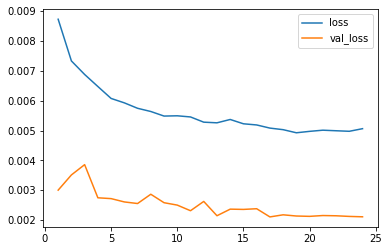

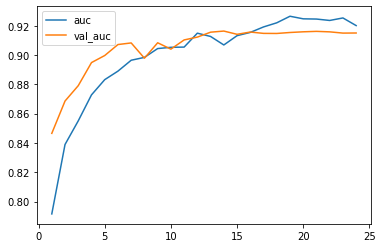

In [13]:
history_df = pd.DataFrame(history.history)
history_df.loc[1:, ['loss', 'val_loss']].plot()
history_df.loc[1:, ['auc', 'val_auc']].plot()

In [14]:
preds_eval = []
for model in models:
    preds_eval.append(model.predict(X))
    
print(classification_report(y, np.round(np.average(np.array(preds_eval),axis=0))))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    200000
         1.0       0.86      0.45      0.59       961

    accuracy                           1.00    200961
   macro avg       0.93      0.72      0.79    200961
weighted avg       1.00      1.00      1.00    200961



In [15]:
pred = np.average(np.array(preds),axis=0)
pred

array([[0.27721775],
       [0.22182563],
       [0.15629563],
       ...,
       [0.25549105],
       [0.1583056 ],
       [0.19580314]], dtype=float32)

In [16]:
submission['Class'] = pred
submission['Class'] = submission['Class'].clip(0,1)
submission

,id,Class
0,219129,0.277218
1,219130,0.221826
2,219131,0.156296
3,219132,0.285377
4,219133,0.206943
...,...,...
146082,365211,0.196192
146083,365212,0.241763
146084,365213,0.255491
146085,365214,0.158306


In [17]:
submission.to_csv('submission.csv', index=False)

<AxesSubplot:>

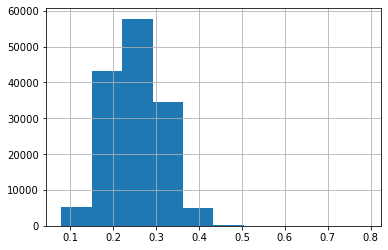

In [18]:
submission.Class.hist()